In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys
import matplotlib as mpl
import os
from pathlib import Path
sys.path.append('..')
import strings as cs

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "strings").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

BACKEND = "fortran"  
if BACKEND == "fortran":
    sys.path.insert(0, str(PROJECT_ROOT / "fortran_backend"))
    import cosmic_cl_backend as fcl

    compute_cl_backend = fcl.compute_cl
    theory_settings = dict(
        n_k=48,
        n_chi=1024,
        k_min=1.0e-4,
        k_max=1.0e-1,
    )
elif BACKEND == "python":
    compute_cl_backend = cs.compute_cl
    theory_settings = dict(
        N_k=30,
        max_workers=8,
        progress=True,
    )
else:
    raise ValueError("BACKEND must be 'fortran' or 'python'")

BACKEND, theory_settings

TEX_BIN = "/Library/TeX/texbin"
if Path(TEX_BIN).exists() and TEX_BIN not in os.environ.get("PATH", "").split(":"):
    os.environ["PATH"] = f"{TEX_BIN}:{os.environ.get('PATH', '')}"

mpl.rcParams["text.usetex"] = True
mpl.rcParams["font.family"] = "serif"
mpl.rcParams["font.serif"] = ["Computer Modern Roman"]
mpl.rcParams["font.size"] = 14
mpl.rcParams["text.usetex"] = True
mpl.rcParams["font.family"] = "serif"
mpl.rcParams["font.serif"] = ["Computer Modern Roman"]

In [2]:
ACT = cs.ACTDR6
PLANCK = cs.PLANCK18
PLANCK13 = cs.PLANCK13
ACTCOV = cs.ACTCOV

In [3]:
l = np.arange(2, 2000)[::2]
theory = compute_cl_backend(5e-5, 1,ell_arr=l)

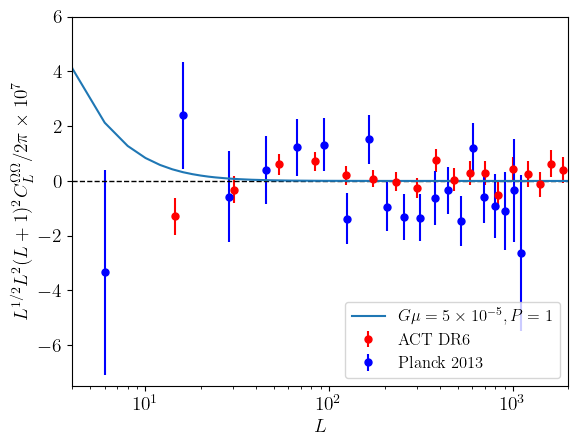

In [4]:
plt.errorbar(ACT.L, ACT.CL*cs.DR6_FACTOR(ACT.L)*1e7, yerr=ACT.ER*cs.DR6_FACTOR(ACT.L)*1e7, label='ACT DR6', color='red', fmt='o', markersize=5)
plt.errorbar(PLANCK13.L, PLANCK13.CL*cs.DR6_FACTOR(PLANCK13.L)*1e7, yerr=PLANCK13.ER*cs.DR6_FACTOR(PLANCK13.L)*1e7, fmt='o', label='Planck 2013', color='blue', markersize=5)
#plt.errorbar(PLANCK.L, PLANCK.CL*cs.DR6_FACTOR(PLANCK.L)*1e7, yerr=PLANCK.ER*cs.DR6_FACTOR(PLANCK.L)*1e7, fmt='o', label='Planck 2018', color='green', markersize=5)
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.plot(l, theory*cs.DR6_FACTOR(l)*1e7, label=r'$G\mu=5\times10^{-5}, P=1$')
plt.semilogx()
plt.xlim(4, 2000)
plt.ylim(-7.5, 6)
plt.xlabel(r'$L$', fontsize=14)
plt.ylabel(r'$L^{1/2} L^2(L+1)^2 C_L^{\Omega \Omega}/{2\pi} \times 10^{7}$', fontsize=14)
plt.legend(fontsize=12,loc='lower right')
plt.savefig('plots/GmuP_Cl.pdf', dpi=300, bbox_inches='tight')